# Solar Cycle Peak Forecasting — Phase 0: Data Acquisition & EDA

**Dataset:** SILSO Monthly Total Sunspot Number, Version 2.0  
**Period:** 1749 – Present  
**Steps:** Data loading → Quality checks → Visualisations → Cycle minima/maxima


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


## Step 0.1–0.2 · Load Dataset

In [2]:
# SILSO V2.0 monthly total sunspot number
# Columns: Year ; Month ; DecimalYear ; SN ; StdDev ; Observations ; Provisional
COL_NAMES = ["Year", "Month", "DecimalYear", "SN", "StdDev", "Observations", "Provisional"]

df_raw = pd.read_csv(
    "SN_m_tot_V2.0.csv",
    sep=";",
    header=None,
    names=COL_NAMES,
    skipinitialspace=True,
)

# Parse dates
df_raw["Date"] = pd.to_datetime(
    df_raw["Year"].astype(str) + "-" + df_raw["Month"].astype(str).str.zfill(2),
    format="%Y-%m",
)

# Sort chronologically (should already be sorted, but enforce it)
df_raw = df_raw.sort_values("Date").reset_index(drop=True)

print(f"Shape : {df_raw.shape}")
print(f"Period: {df_raw['Date'].iloc[0].strftime('%Y-%m')}  →  {df_raw['Date'].iloc[-1].strftime('%Y-%m')}")
df_raw.head(8)


Shape : (3329, 8)
Period: 1749-01  →  2026-05


,Year,Month,DecimalYear,SN,StdDev,Observations,Provisional,Date
0,1749,1,1749.042,96.7,-1.0,-1,1,1749-01-01
1,1749,2,1749.123,104.3,-1.0,-1,1,1749-02-01
2,1749,3,1749.204,116.7,-1.0,-1,1,1749-03-01
3,1749,4,1749.288,92.8,-1.0,-1,1,1749-04-01
4,1749,5,1749.371,141.7,-1.0,-1,1,1749-05-01
5,1749,6,1749.455,139.2,-1.0,-1,1,1749-06-01
6,1749,7,1749.538,158.0,-1.0,-1,1,1749-07-01
7,1749,8,1749.623,110.5,-1.0,-1,1,1749-08-01


## Step 0.3 · Data Quality Checks

In [3]:
qc = {}

# 1. Missing values
qc["missing_values"] = df_raw.isnull().sum().to_dict()

# 2. Duplicate rows (by Date)
dup_mask = df_raw.duplicated(subset="Date", keep=False)
qc["duplicate_dates"] = int(dup_mask.sum())

# 3. Invalid dates (already parsed; check for NaT)
qc["invalid_dates"] = int(df_raw["Date"].isna().sum())

# 4. Negative sunspot numbers
#    SILSO uses -1 as a sentinel for missing/uncertain observations
neg_mask = df_raw["SN"] < 0
qc["negative_SN_rows"] = int(neg_mask.sum())
qc["sentinel_minus1_rows"] = int((df_raw["SN"] == -1).sum())

# 5. Date continuity (check for gaps)
expected_months = pd.date_range(df_raw["Date"].iloc[0], df_raw["Date"].iloc[-1], freq="MS")
actual_months   = set(df_raw["Date"])
missing_months  = [d for d in expected_months if d not in actual_months]
qc["missing_months_in_sequence"] = len(missing_months)

# 6. Basic stats
qc["total_records"] = len(df_raw)
qc["SN_min"]  = float(df_raw["SN"].min())
qc["SN_max"]  = float(df_raw["SN"].max())
qc["SN_mean"] = float(df_raw["SN"].mean().round(2))

# ── Print report ──────────────────────────────────────────────────────────────
print("=" * 50)
print("       DATA QUALITY REPORT — SILSO SN V2.0")
print("=" * 50)
for k, v in qc.items():
    print(f"  {k:<35s}: {v}")
print("=" * 50)

# Flag whether data is clean enough to proceed
issues = [
    qc["duplicate_dates"] > 0,
    qc["invalid_dates"] > 0,
    qc["missing_months_in_sequence"] > 0,
    qc["negative_SN_rows"] > qc["sentinel_minus1_rows"],   # non-sentinel negatives
]
print()
if any(issues):
    print("⚠  Issues found — review before proceeding.")
else:
    print("✓  No structural issues. Dataset is clean.")


       DATA QUALITY REPORT — SILSO SN V2.0
  missing_values                     : {'Year': 0, 'Month': 0, 'DecimalYear': 0, 'SN': 0, 'StdDev': 0, 'Observations': 0, 'Provisional': 0, 'Date': 0}
  duplicate_dates                    : 0
  invalid_dates                      : 0
  negative_SN_rows                   : 0
  sentinel_minus1_rows               : 0
  missing_months_in_sequence         : 0
  total_records                      : 3329
  SN_min                             : 0.0
  SN_max                             : 398.2
  SN_mean                            : 82.2

✓  No structural issues. Dataset is clean.


In [4]:
# Replace SILSO sentinel (-1) with NaN for analysis; keep original column intact
df = df_raw.copy()
df["SN_clean"] = df["SN"].where(df["SN"] >= 0, np.nan)

print(f"Working DataFrame shape : {df.shape}")
print(f"NaN in SN_clean         : {df['SN_clean'].isna().sum()}")
df[["Date", "SN", "SN_clean", "StdDev", "Provisional"]].head(10)


Working DataFrame shape : (3329, 9)
NaN in SN_clean         : 0


,Date,SN,SN_clean,StdDev,Provisional
0,1749-01-01,96.7,96.7,-1.0,1
1,1749-02-01,104.3,104.3,-1.0,1
2,1749-03-01,116.7,116.7,-1.0,1
3,1749-04-01,92.8,92.8,-1.0,1
4,1749-05-01,141.7,141.7,-1.0,1
5,1749-06-01,139.2,139.2,-1.0,1
6,1749-07-01,158.0,158.0,-1.0,1
7,1749-08-01,110.5,110.5,-1.0,1
8,1749-09-01,126.5,126.5,-1.0,1
9,1749-10-01,125.8,125.8,-1.0,1


## Step 0.4 · EDA Visualisations

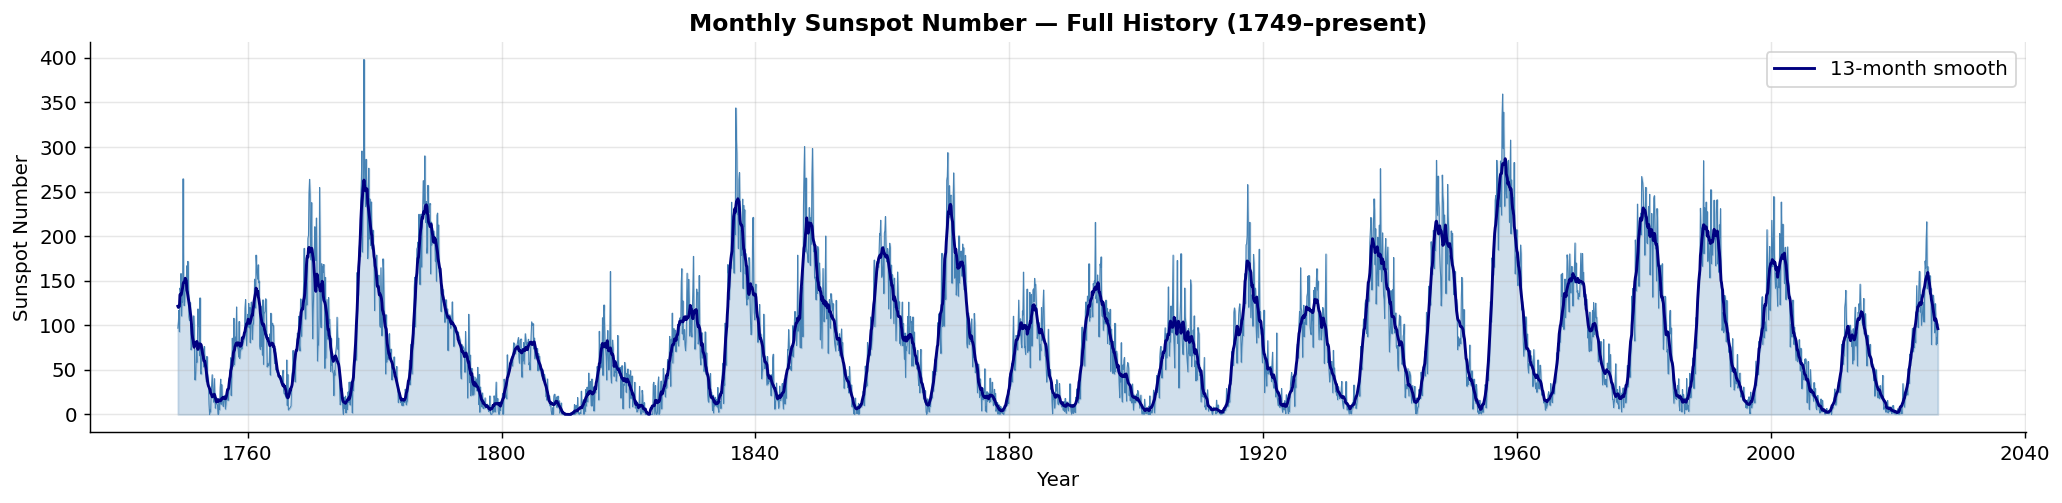

Saved: plot_full_history.png


In [5]:
# ── Plot 1: Full history 1749 – present ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

ax.fill_between(df["Date"], df["SN_clean"], alpha=0.25, color="steelblue")
ax.plot(df["Date"], df["SN_clean"], lw=0.6, color="steelblue")

# 13-month running mean
df["SN_13m"] = df["SN_clean"].rolling(13, center=True, min_periods=7).mean()
ax.plot(df["Date"], df["SN_13m"], lw=1.6, color="navy", label="13-month smooth")

ax.set_title("Monthly Sunspot Number — Full History (1749–present)", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Sunspot Number")
ax.legend()
plt.tight_layout()
plt.savefig("plot_full_history.png", dpi=150)
plt.show()
print("Saved: plot_full_history.png")


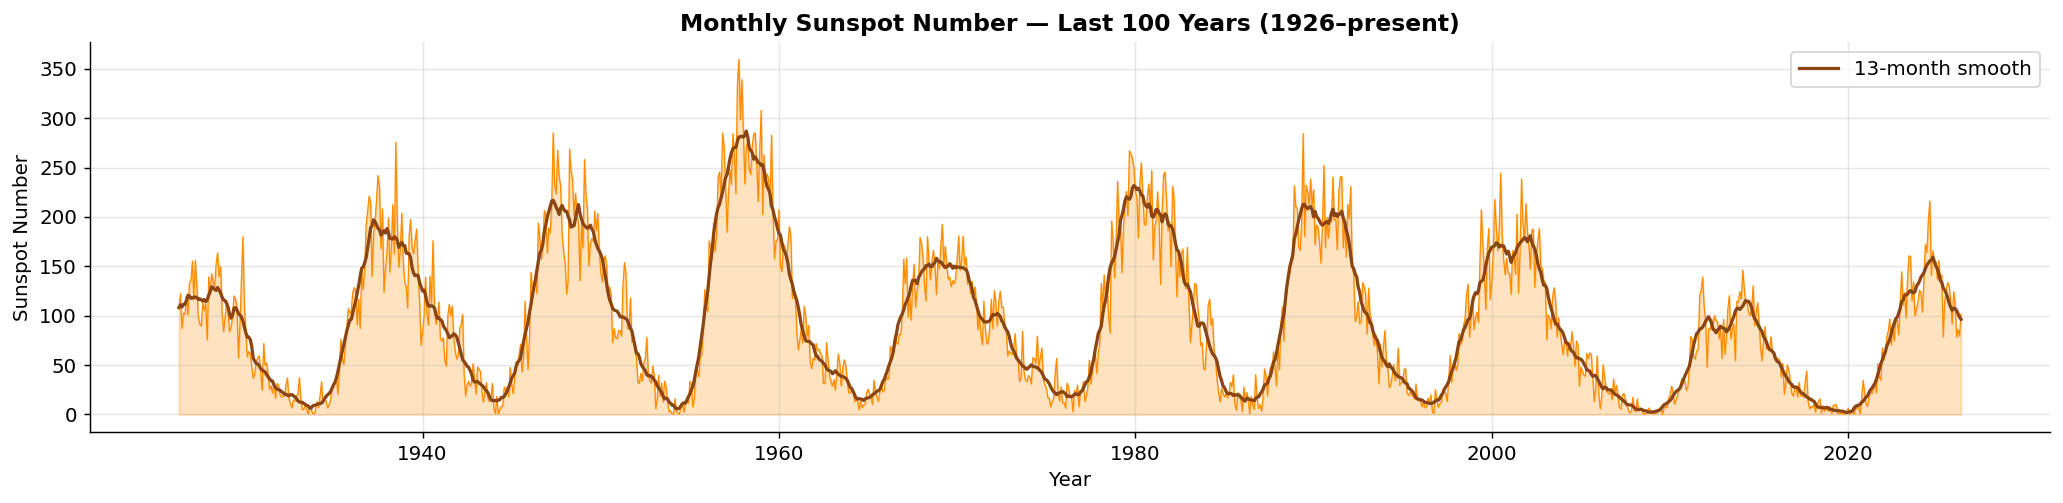

Saved: plot_last_100yr.png


In [6]:
# ── Plot 2: Last 100 years ────────────────────────────────────────────────────
cutoff_100 = df["Date"].iloc[-1] - pd.DateOffset(years=100)
df_100 = df[df["Date"] >= cutoff_100]

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(df_100["Date"], df_100["SN_clean"], alpha=0.25, color="darkorange")
ax.plot(df_100["Date"], df_100["SN_clean"], lw=0.7, color="darkorange")
ax.plot(df_100["Date"], df_100["SN_13m"], lw=1.8, color="saddlebrown", label="13-month smooth")

ax.set_title(f"Monthly Sunspot Number — Last 100 Years ({df_100['Date'].iloc[0].year}–present)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Sunspot Number")
ax.legend()
plt.tight_layout()
plt.savefig("plot_last_100yr.png", dpi=150)
plt.show()
print("Saved: plot_last_100yr.png")


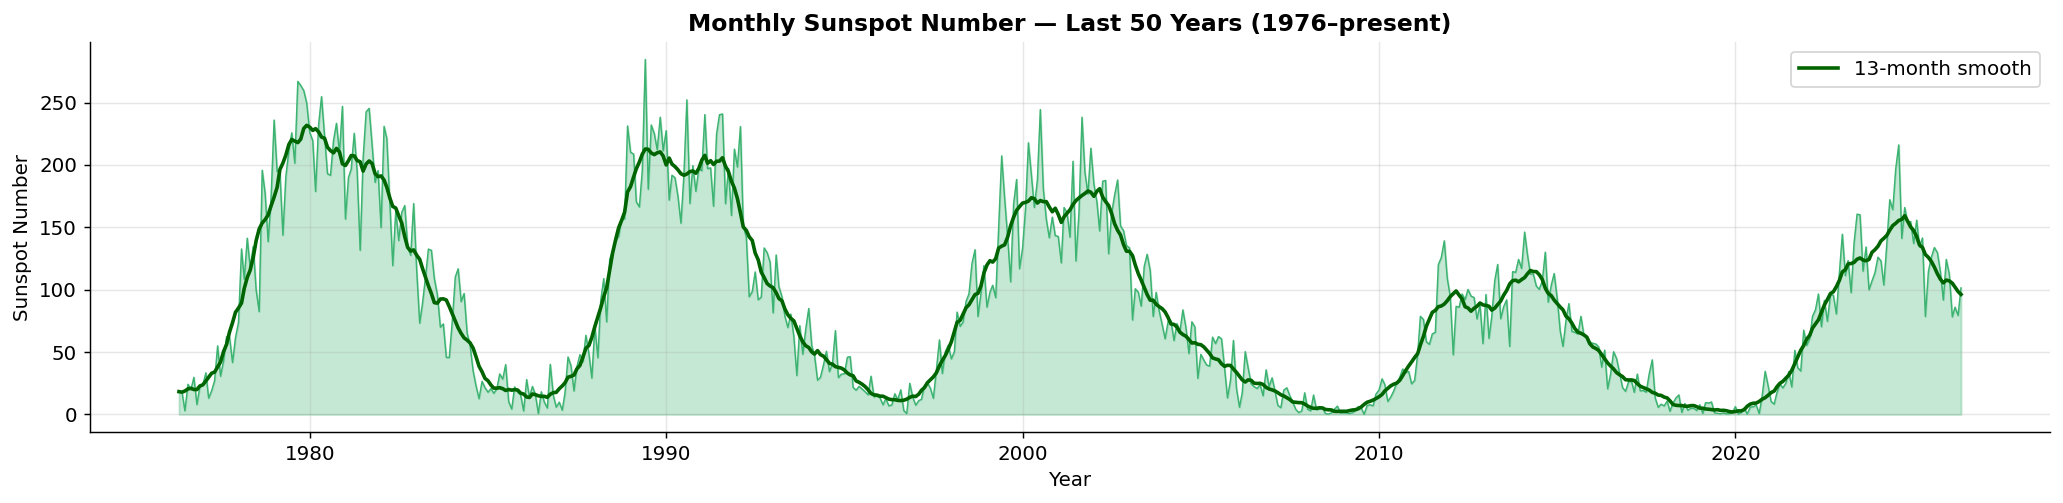

Saved: plot_last_50yr.png


In [7]:
# ── Plot 3: Last 50 years ─────────────────────────────────────────────────────
cutoff_50 = df["Date"].iloc[-1] - pd.DateOffset(years=50)
df_50 = df[df["Date"] >= cutoff_50]

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(df_50["Date"], df_50["SN_clean"], alpha=0.3, color="mediumseagreen")
ax.plot(df_50["Date"], df_50["SN_clean"], lw=0.8, color="mediumseagreen")
ax.plot(df_50["Date"], df_50["SN_13m"], lw=2.0, color="darkgreen", label="13-month smooth")

ax.set_title(f"Monthly Sunspot Number — Last 50 Years ({df_50['Date'].iloc[0].year}–present)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Sunspot Number")
ax.legend()
plt.tight_layout()
plt.savefig("plot_last_50yr.png", dpi=150)
plt.show()
print("Saved: plot_last_50yr.png")


C:\Users\anish\AppData\Local\Temp\ipykernel_2968\887654142.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(decade_groups, labels=decade_labels, notch=False, patch_artist=True,


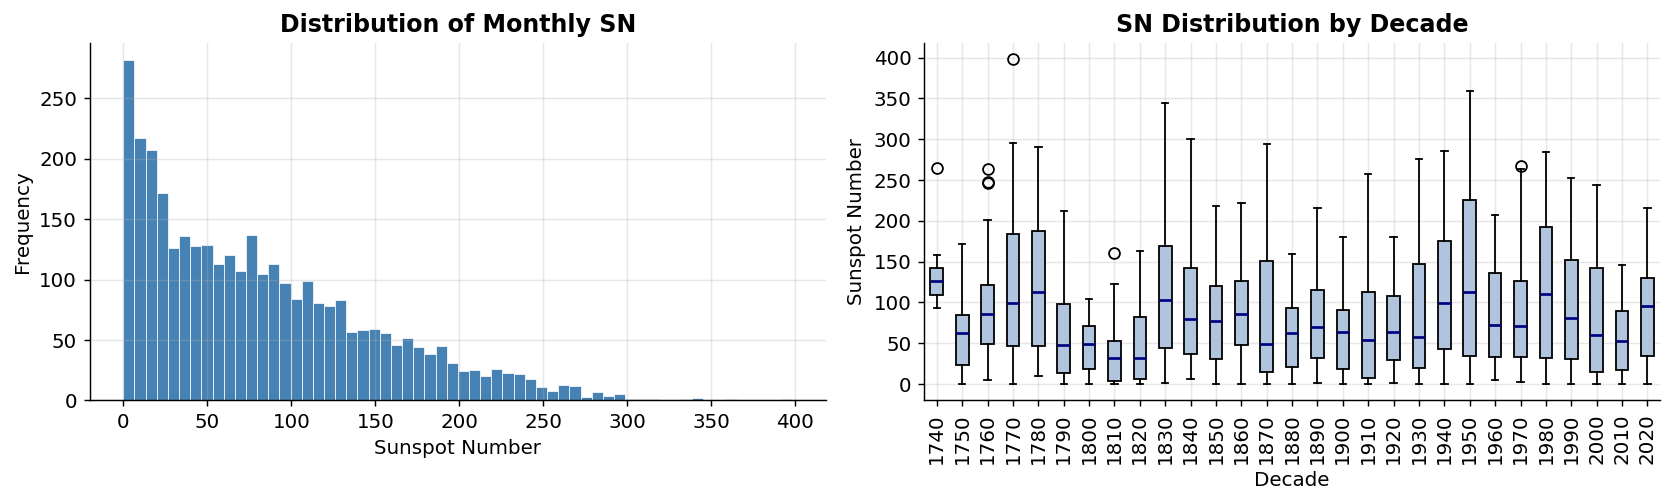

Saved: plot_distribution.png

count    3329.0
mean       82.2
std        67.6
min         0.0
25%        24.4
50%        68.5
75%       123.0
max       398.2


In [8]:
# ── Plot 4: Distribution & descriptive stats ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["SN_clean"].dropna(), bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_title("Distribution of Monthly SN", fontweight="bold")
axes[0].set_xlabel("Sunspot Number")
axes[0].set_ylabel("Frequency")

# Decade-level boxplot
df["Decade"] = (df["Date"].dt.year // 10 * 10).astype(str)
decade_groups = [g["SN_clean"].dropna().values for _, g in df.groupby("Decade")]
decade_labels = sorted(df["Decade"].unique())
axes[1].boxplot(decade_groups, labels=decade_labels, notch=False, patch_artist=True,
                boxprops=dict(facecolor="lightsteelblue"), medianprops=dict(color="navy", lw=1.5))
axes[1].set_title("SN Distribution by Decade", fontweight="bold")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Sunspot Number")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig("plot_distribution.png", dpi=150)
plt.show()
print("Saved: plot_distribution.png")

print()
print(df["SN_clean"].describe().round(2).to_string())


## Step 0.5 · Solar Cycle Minima & Maxima

In [12]:
# ── Load the official SILSO cycle table ───────────────────────────────────────
cyc_raw = pd.read_csv("TableCyclesMiMa.csv", sep=";", header=None, skiprows=2, encoding="latin-1",
                       names=["Cycle_ID","Min_Year","Min_Month","Min_SN",
                               "Max_Year","Max_Month","Max_SN"])

# Strip whitespace, coerce
for col in cyc_raw.columns:
    cyc_raw[col] = cyc_raw[col].astype(str).str.strip()

cyc_raw = cyc_raw[cyc_raw["Cycle_ID"].str.isnumeric()].copy()
cyc_raw = cyc_raw.apply(pd.to_numeric, errors="coerce")
cyc_raw.reset_index(drop=True, inplace=True)

# Build datetime columns
def ym_to_date(yr, mo):
    return pd.to_datetime(
        yr.astype("Int64").astype(str) + "-" + mo.astype("Int64").astype(str).str.zfill(2),
        format="%Y-%m", errors="coerce"
    )

cyc_raw["Start_Date"] = ym_to_date(cyc_raw["Min_Year"], cyc_raw["Min_Month"])
cyc_raw["Peak_Date"]  = ym_to_date(cyc_raw["Max_Year"], cyc_raw["Max_Month"])

# End date = next cycle's start date
cyc_raw["End_Date"] = cyc_raw["Start_Date"].shift(-1)

# Derived features
cyc_raw["Cycle_Length_months"] = (
    (cyc_raw["End_Date"] - cyc_raw["Start_Date"]) / pd.Timedelta(days=30.4375)
).round(1)

cyc_raw["Rise_Time_months"] = (
    (cyc_raw["Peak_Date"] - cyc_raw["Start_Date"]) / pd.Timedelta(days=30.4375)
).round(1)

cyc_raw["Decay_Time_months"] = (
    (cyc_raw["End_Date"] - cyc_raw["Peak_Date"]) / pd.Timedelta(days=30.4375)
).round(1)

cycle_db = cyc_raw[[
    "Cycle_ID", "Start_Date", "End_Date", "Peak_Date",
    "Min_SN", "Max_SN",
    "Cycle_Length_months", "Rise_Time_months", "Decay_Time_months"
]].rename(columns={"Min_SN": "Min_Sunspot_Number", "Max_SN": "Peak_Sunspot_Number"})

print(f"Cycles in database: {len(cycle_db)}")
cycle_db


Cycles in database: 25


,Cycle_ID,Start_Date,End_Date,Peak_Date,Min_Sunspot_Number,Peak_Sunspot_Number,Cycle_Length_months,Rise_Time_months,Decay_Time_months
0,1,1755-02-01,1766-06-01,1761-06-01,14.0,144.1,136.0,76.0,60.0
1,2,1766-06-01,1775-06-01,1769-09-01,18.6,193.0,108.0,39.0,69.0
2,3,1775-06-01,1784-09-01,1778-05-01,12.0,264.2,111.0,35.0,76.1
3,4,1784-09-01,1798-04-01,1788-02-01,15.9,235.3,163.0,41.0,122.0
4,5,1798-04-01,1810-07-01,1805-02-01,5.3,82.0,147.0,82.0,64.9
5,6,1810-07-01,1823-05-01,1816-05-01,0.0,81.2,154.0,70.0,84.0
6,7,1823-05-01,1833-11-01,1829-11-01,0.1,119.2,126.1,78.1,48.0
7,8,1833-11-01,1843-07-01,1837-03-01,12.2,244.9,115.9,40.0,76.0
8,9,1843-07-01,1855-12-01,1848-02-01,17.6,219.9,149.0,55.1,94.0
9,10,1855-12-01,1867-03-01,1860-02-01,6.0,186.2,135.0,50.0,84.9


In [13]:
# ── Summary statistics ────────────────────────────────────────────────────────
numeric_cols = ["Peak_Sunspot_Number", "Cycle_Length_months", "Rise_Time_months", "Decay_Time_months"]
print("Cycle Database — Summary Statistics")
print("=" * 55)
print(cycle_db[numeric_cols].describe().round(1).to_string())


Cycle Database — Summary Statistics
       Peak_Sunspot_Number  Cycle_Length_months  Rise_Time_months  Decay_Time_months
count                 24.0                 24.0              24.0               24.0
mean                 178.7                132.4              52.3               80.1
std                   57.8                 13.9              13.6               14.9
min                   81.2                108.0              35.0               48.0
25%                  128.8                121.8              41.0               71.2
50%                  183.2                133.5              49.0               81.0
75%                  223.2                141.2              60.8               85.8
max                  285.0                163.0              82.0              122.0


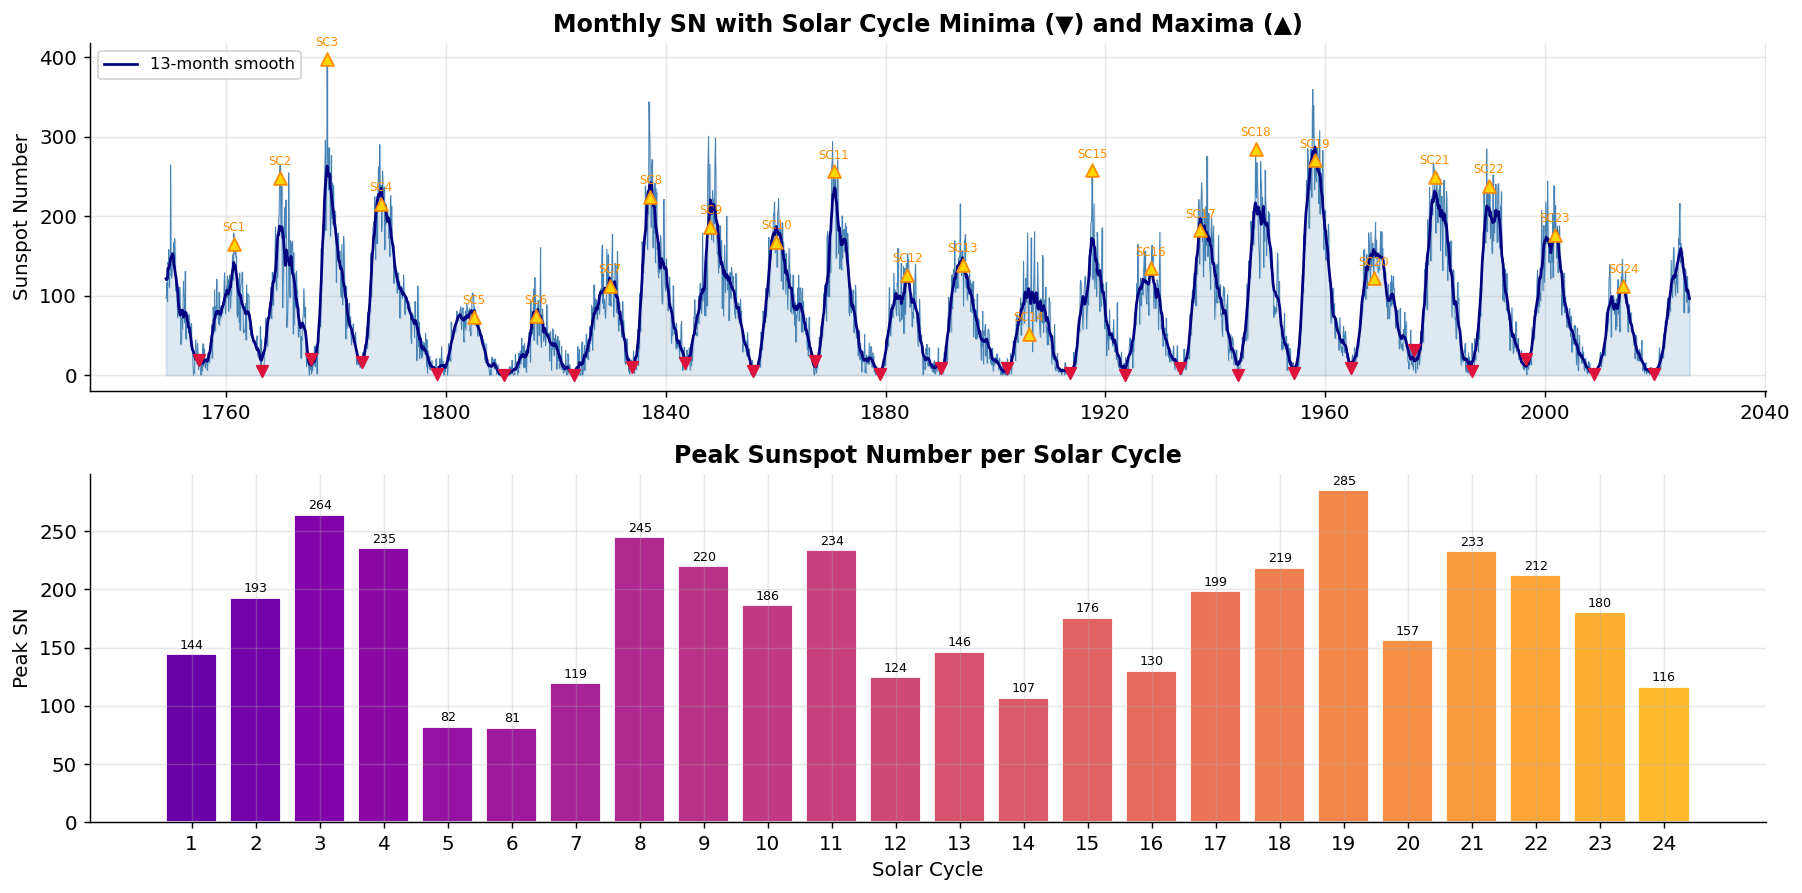

Saved: plot_cycles_overview.png


In [14]:
# ── Plot: Cycle peaks over time ───────────────────────────────────────────────
valid = cycle_db.dropna(subset=["Peak_Date", "Peak_Sunspot_Number"])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Top: full SN with minima & maxima annotated
ax = axes[0]
ax.fill_between(df["Date"], df["SN_clean"], alpha=0.18, color="steelblue")
ax.plot(df["Date"], df["SN_clean"], lw=0.5, color="steelblue")
ax.plot(df["Date"], df["SN_13m"], lw=1.5, color="navy", label="13-month smooth")

# Mark minima
min_dates = cycle_db["Start_Date"].dropna()
min_vals  = [df.loc[df["Date"] == d, "SN_clean"].values for d in min_dates]
for d, v in zip(min_dates, min_vals):
    if len(v) > 0:
        ax.scatter(d, v[0], marker="v", s=40, color="crimson", zorder=5)

# Mark maxima
for _, row in valid.iterrows():
    d = row["Peak_Date"]
    v_arr = df.loc[df["Date"] == d, "SN_clean"].values
    val = v_arr[0] if len(v_arr) > 0 else row["Peak_Sunspot_Number"]
    ax.scatter(d, val, marker="^", s=50, color="gold", edgecolors="darkorange", zorder=5)
    ax.annotate(f"SC{int(row['Cycle_ID'])}", (d, val),
                textcoords="offset points", xytext=(0, 7),
                fontsize=6.5, ha="center", color="darkorange")

ax.set_title("Monthly SN with Solar Cycle Minima (▼) and Maxima (▲)", fontweight="bold")
ax.set_ylabel("Sunspot Number")
ax.legend(loc="upper left", fontsize=9)

# Bottom: bar chart of peak magnitudes
ax2 = axes[1]
colors = plt.cm.plasma(np.linspace(0.2, 0.85, len(valid)))
bars = ax2.bar(valid["Cycle_ID"].astype(int), valid["Peak_Sunspot_Number"], color=colors, edgecolor="white")
ax2.set_title("Peak Sunspot Number per Solar Cycle", fontweight="bold")
ax2.set_xlabel("Solar Cycle")
ax2.set_ylabel("Peak SN")
ax2.set_xticks(valid["Cycle_ID"].astype(int))
for bar, val in zip(bars, valid["Peak_Sunspot_Number"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{val:.0f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("plot_cycles_overview.png", dpi=150)
plt.show()
print("Saved: plot_cycles_overview.png")


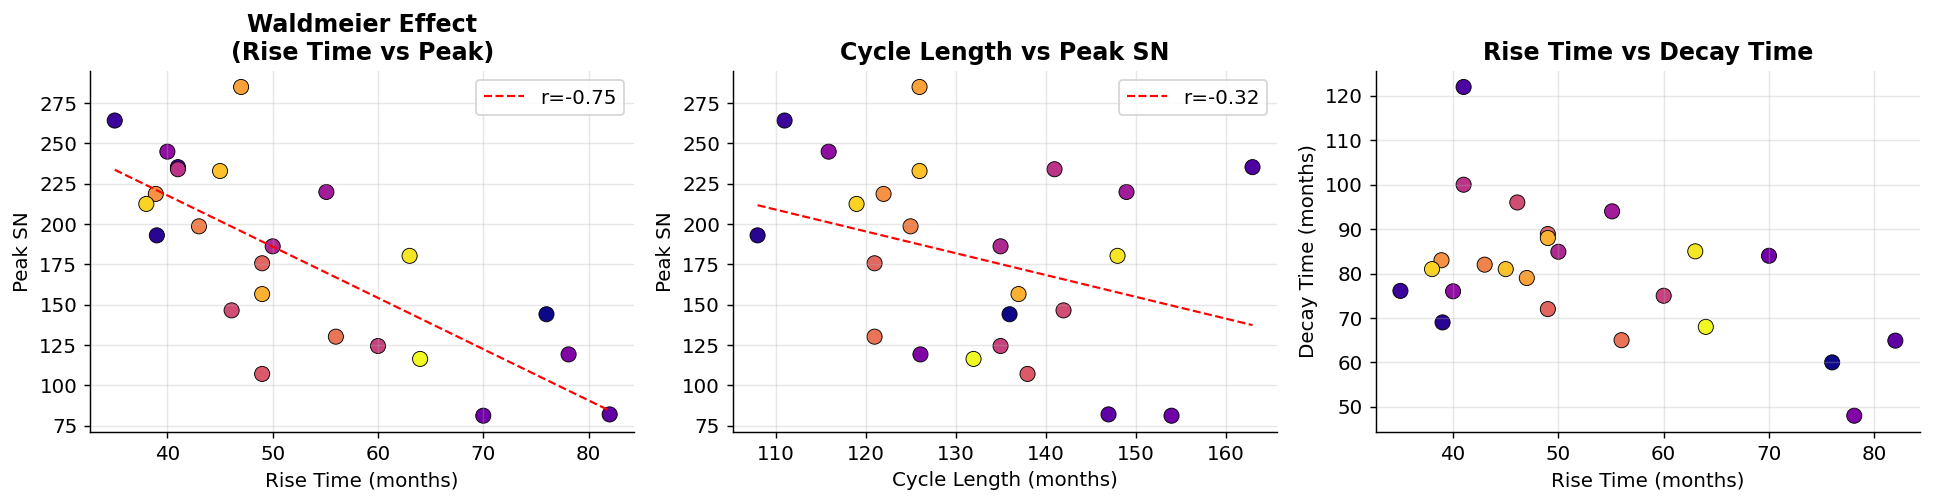

Saved: plot_cycle_relationships.png


In [15]:
# ── Plot: Rise time vs Peak magnitude (Waldmeier effect) ─────────────────────
valid2 = cycle_db.dropna(subset=["Rise_Time_months","Peak_Sunspot_Number","Cycle_Length_months"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Rise time vs Peak
axes[0].scatter(valid2["Rise_Time_months"], valid2["Peak_Sunspot_Number"],
                c=valid2["Cycle_ID"], cmap="plasma", s=70, edgecolors="k", linewidths=0.5)
m, b = np.polyfit(valid2["Rise_Time_months"].dropna(),
                  valid2["Peak_Sunspot_Number"].dropna(), 1)
x = np.linspace(valid2["Rise_Time_months"].min(), valid2["Rise_Time_months"].max(), 100)
axes[0].plot(x, m*x+b, "r--", lw=1.2, label=f"r={np.corrcoef(valid2['Rise_Time_months'].dropna(), valid2['Peak_Sunspot_Number'].dropna())[0,1]:.2f}")
axes[0].set_xlabel("Rise Time (months)")
axes[0].set_ylabel("Peak SN")
axes[0].set_title("Waldmeier Effect\n(Rise Time vs Peak)", fontweight="bold")
axes[0].legend()

# 2. Cycle length vs Peak
axes[1].scatter(valid2["Cycle_Length_months"], valid2["Peak_Sunspot_Number"],
                c=valid2["Cycle_ID"], cmap="plasma", s=70, edgecolors="k", linewidths=0.5)
m2, b2 = np.polyfit(valid2["Cycle_Length_months"].dropna(),
                    valid2["Peak_Sunspot_Number"].dropna(), 1)
x2 = np.linspace(valid2["Cycle_Length_months"].min(), valid2["Cycle_Length_months"].max(), 100)
axes[1].plot(x2, m2*x2+b2, "r--", lw=1.2, label=f"r={np.corrcoef(valid2['Cycle_Length_months'].dropna(), valid2['Peak_Sunspot_Number'].dropna())[0,1]:.2f}")
axes[1].set_xlabel("Cycle Length (months)")
axes[1].set_ylabel("Peak SN")
axes[1].set_title("Cycle Length vs Peak SN", fontweight="bold")
axes[1].legend()

# 3. Rise vs Decay time
valid3 = cycle_db.dropna(subset=["Rise_Time_months","Decay_Time_months"])
axes[2].scatter(valid3["Rise_Time_months"], valid3["Decay_Time_months"],
                c=valid3["Cycle_ID"], cmap="plasma", s=70, edgecolors="k", linewidths=0.5)
axes[2].set_xlabel("Rise Time (months)")
axes[2].set_ylabel("Decay Time (months)")
axes[2].set_title("Rise Time vs Decay Time", fontweight="bold")

plt.tight_layout()
plt.savefig("plot_cycle_relationships.png", dpi=150)
plt.show()
print("Saved: plot_cycle_relationships.png")


In [16]:
# ── Save Cycle Database CSV ───────────────────────────────────────────────────
cycle_db.to_csv("Cycle_Database.csv", index=False)
print("Saved: Cycle_Database.csv")
print()
print(cycle_db.to_string(index=False))


Saved: Cycle_Database.csv

 Cycle_ID Start_Date   End_Date  Peak_Date  Min_Sunspot_Number  Peak_Sunspot_Number  Cycle_Length_months  Rise_Time_months  Decay_Time_months
        1 1755-02-01 1766-06-01 1761-06-01                14.0                144.1                136.0              76.0               60.0
        2 1766-06-01 1775-06-01 1769-09-01                18.6                193.0                108.0              39.0               69.0
        3 1775-06-01 1784-09-01 1778-05-01                12.0                264.2                111.0              35.0               76.1
        4 1784-09-01 1798-04-01 1788-02-01                15.9                235.3                163.0              41.0              122.0
        5 1798-04-01 1810-07-01 1805-02-01                 5.3                 82.0                147.0              82.0               64.9
        6 1810-07-01 1823-05-01 1816-05-01                 0.0                 81.2                154.0              70.

In [17]:
# ── Save cleaned monthly dataset ─────────────────────────────────────────────
df_save = df[["Date","Year","Month","SN","SN_clean","StdDev","Observations","Provisional"]].copy()
df_save.to_csv("SN_monthly_clean.csv", index=False)
print("Saved: SN_monthly_clean.csv")
print(f"Shape: {df_save.shape}")


Saved: SN_monthly_clean.csv
Shape: (3329, 8)


## Phase 0 Complete ✓

| Output | Description |
|--------|-------------|
| `SN_monthly_clean.csv` | Cleaned monthly SN dataset (1749–present) |
| `Cycle_Database.csv` | One row per solar cycle (SC1–SC25) with start/peak/end dates and derived features |
| `plot_full_history.png` | Full 1749–present time series |
| `plot_last_100yr.png` | Last 100 years |
| `plot_last_50yr.png` | Last 50 years |
| `plot_distribution.png` | SN distribution + decade boxplots |
| `plot_cycles_overview.png` | Cycles annotated + peak bar chart |
| `plot_cycle_relationships.png` | Waldmeier effect & cycle statistics |

**Next:** Phase 1 — Monthly Sunspot Forecasting
